In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
train=pd.read_csv("fordTrain.csv")

IsAlert
1    349785
0    254544
Name: count, dtype: int64

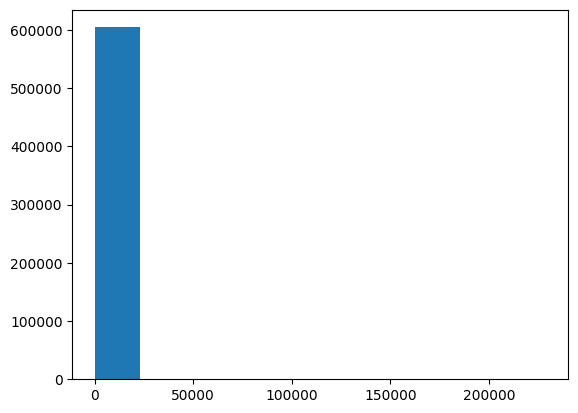

In [3]:
plt.hist(x=train["P6"])
train["IsAlert"].value_counts()

In [4]:
train=train[train["P6"]<=30000]
train=train.drop(columns=["TrialID","V7","V9","P8"])
x=['P3','P6','E3','E4','E6','E7','E8','E9','E10','V3','V5','V6','V10','IsAlert']
for i in x:
    train[i]=train[i].astype('int16')
y=['P1','P2','P4','P5','P7','E1','E2','E5','E11','V1','V2','V4','V8','V11']
for i in y:
    train[i]=train[i].astype('float16')

In [5]:
from sklearn.model_selection import train_test_split

x = train.drop(['IsAlert'], axis='columns')



y=train['IsAlert']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3)

In [6]:
%%time
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()
model.fit(x_train,y_train)

CPU times: total: 2min 25s
Wall time: 2min 27s


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [7]:
%%time
y_pred=model.predict(x_test)
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9936561524288662
CPU times: total: 3.42 s
Wall time: 3.58 s
